<a href="https://colab.research.google.com/github/Light466/My_Programs/blob/main/Handwritten_alphabet_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install -q extra-keras-datasets

In [11]:
!pip install -q datasets

In [12]:
from datasets import load_dataset

dataset = load_dataset("tanganke/emnist_letters")

print(dataset)

README.md:   0%|          | 0.00/1.61k [00:00<?, ?B/s]

emnist-letters/train-00000-of-00001.parq(…): reconstructing file:   0%|          |  0.00B / 50.6MB            

emnist-letters/train-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

emnist-letters/test-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 8.41MB            

emnist-letters/test-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/124800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20800 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 124800
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 20800
    })
})


In [13]:
import numpy as np

x_train = np.array([
    np.array(image)
    for image in dataset["train"]["image"]
])

y_train = np.array(dataset["train"]["label"])

x_test = np.array([
    np.array(image)
    for image in dataset["test"]["image"]
])

y_test = np.array(dataset["test"]["label"])

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (124800, 28, 28)
Training labels: (124800,)
Testing images: (20800, 28, 28)
Testing labels: (20800,)


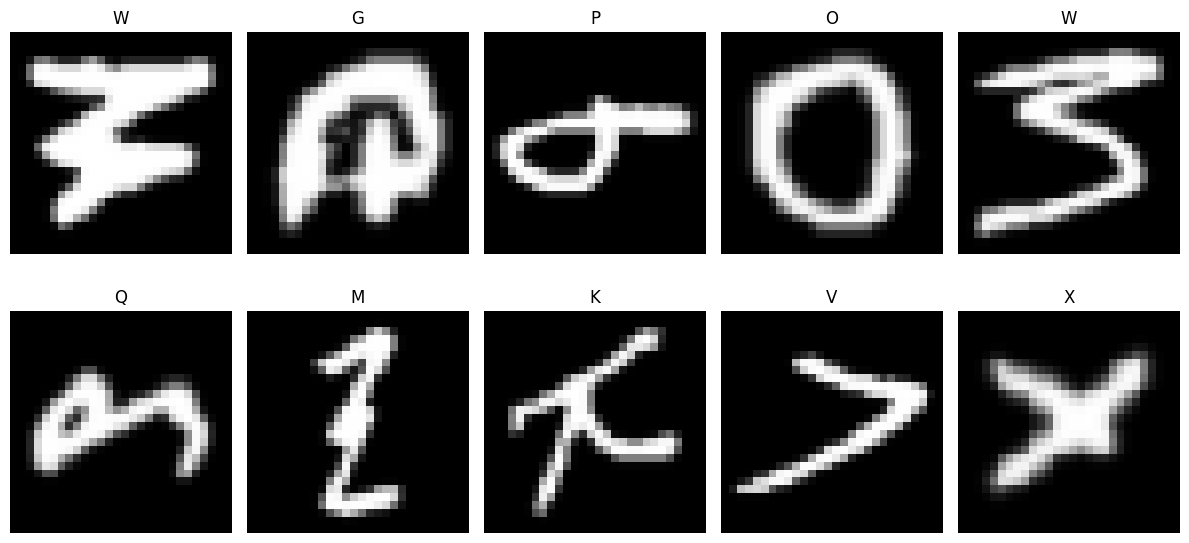

In [14]:
import matplotlib.pyplot as plt

letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_train[i], cmap="gray")

    plt.title(letters[y_train[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)

(124800, 28, 28, 1)


In [16]:
import tensorflow as tf

model = tf.keras.Sequential([

    # Convolution
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Pooling
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convert to one-dimensional vector
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # 26 alphabet classes
    tf.keras.layers.Dense(
        26,
        activation="softmax"
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 696,026 (2.66 MB)

 Trainable params: 696,026 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
878/878 ━━━━━━━━━━━━━━━━━━━━ 55s 60ms/step - accuracy: 0.8081 - loss: 0.6420 - val_accuracy: 0.8869 - val_loss: 0.3606
Epoch 2/10
878/878 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - accuracy: 0.9041 - loss: 0.2997 - val_accuracy: 0.9099 - val_loss: 0.2817
Epoch 3/10
878/878 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.9204 - loss: 0.2432 - val_accuracy: 0.9134 - val_loss: 0.2619
Epoch 4/10
878/878 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.9300 - loss: 0.2097 - val_accuracy: 0.9228 - val_loss: 0.2449
Epoch 5/10
878/878 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.9367 - loss: 0.1858 - val_accuracy: 0.9216 - val_loss: 0.2440
Epoch 6/10
878/878 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.9418 - loss: 0.1668 - val_accuracy: 0.9233 - val_loss: 0.2394
Epoch 7/10
878/878 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.9469 - loss: 0.1507 - val_accuracy: 0.9200 - val_loss: 0.2480
Epoch 8/10
878/878 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.9521 - loss: 0.1343 - 

In [19]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

650/650 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9201 - loss: 0.2774
Test Accuracy: 0.920144259929657


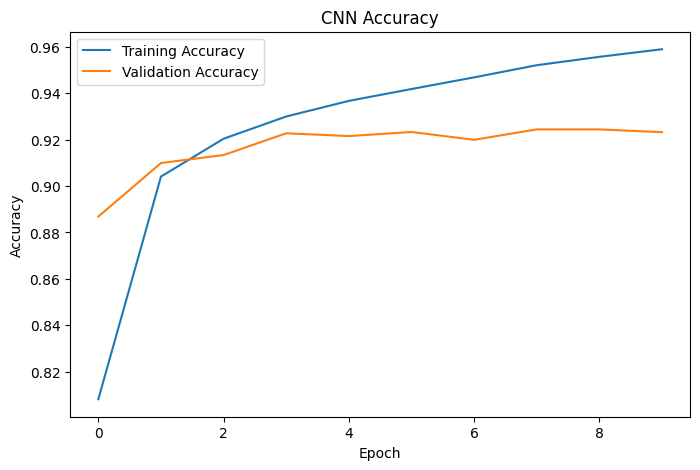

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")

plt.legend()
plt.show()

In [21]:
index = 100

prediction = model.predict(
    x_test[index:index+1],
    verbose=0
)

predicted_number = np.argmax(prediction)

print("Actual Letter:",
      letters[y_test[index]])

print("Predicted Letter:",
      letters[predicted_number])

Actual Letter: A
Predicted Letter: A


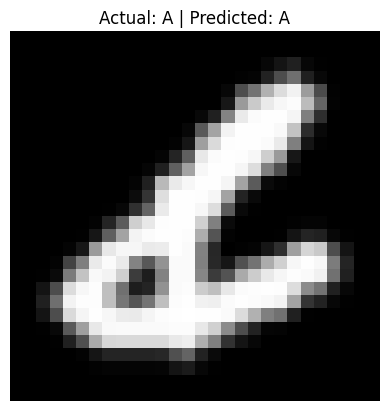

In [22]:
plt.imshow(
    x_test[index].reshape(28, 28),
    cmap="gray"
)

plt.title(
    "Actual: " + letters[y_test[index]] +
    " | Predicted: " + letters[predicted_number]
)

plt.axis("off")
plt.show()

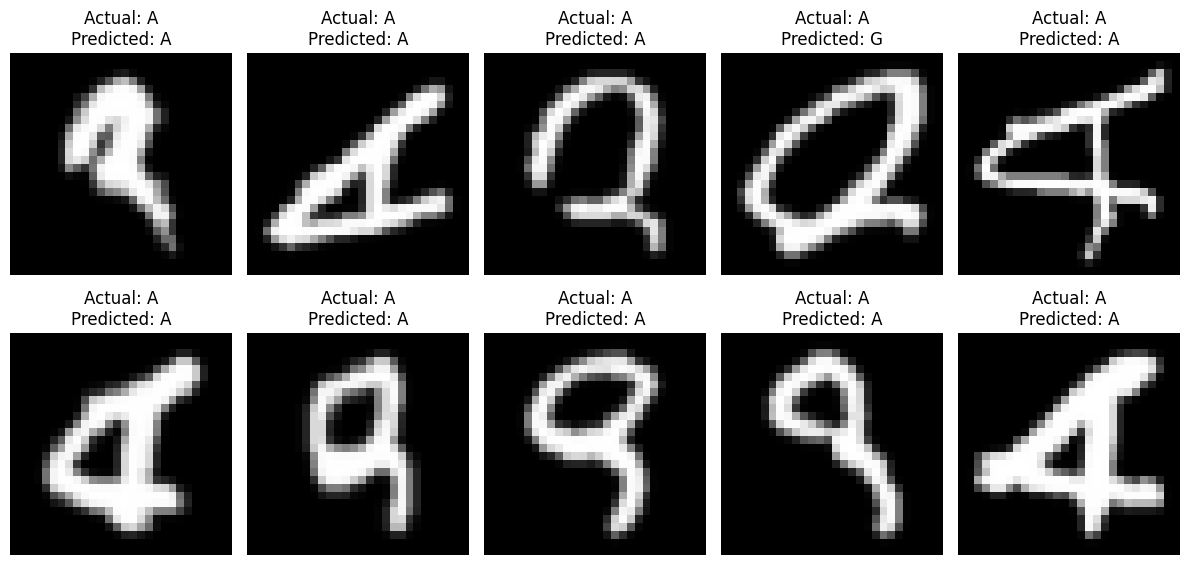

In [23]:
predictions = model.predict(
    x_test[:10],
    verbose=0
)

plt.figure(figsize=(12, 6))

for i in range(10):

    predicted = np.argmax(predictions[i])

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        "Actual: " + letters[y_test[i]] +
        "\nPredicted: " + letters[predicted]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()